# ⚛️ Quantum QUBO Band Selection + Full-Dataset Classical ML
### Salinas Hyperspectral — Google Colab

**Run cells top to bottom. Upload files only once in Cell 2.**

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Install packages
# ═══════════════════════════════════════════════════════════════════════════
import sys, subprocess

packages = ['numpy', 'scipy', 'scikit-learn', 'matplotlib', 'qiskit>=2.0.0']
print('Installing packages...')
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages installed ✓')

Installing packages...
All packages installed ✓


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — Upload files + Load entire dataset
# Run this cell ONCE. All data stays in memory for all later cells.
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import scipy.io
import os
from google.colab import files

print('Please upload BOTH files: Salinas.mat and Salinas_gt.mat')
uploaded = files.upload()
uploaded_names = list(uploaded.keys())
print(f'\nFiles received: {uploaded_names}')

# ── Find which file is which ──────────────────────────────────────────────
salinas_path    = None
salinas_gt_path = None
for name in uploaded_names:
    path = f'/content/{name}'
    if 'gt' in name.lower():
        salinas_gt_path = path
    else:
        salinas_path = path

print(f'  Image file : {salinas_path}')
print(f'  GT file    : {salinas_gt_path}')

if salinas_path is None or salinas_gt_path is None:
    raise FileNotFoundError('Could not find both files. Upload Salinas.mat AND Salinas_gt.mat')

# ── Load .mat files ───────────────────────────────────────────────────────
def get_array(mat_dict, preferred_keys):
    for k in preferred_keys:
        if k in mat_dict:
            return mat_dict[k]
    for k, v in mat_dict.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim >= 2:
            return v
    raise KeyError(f'Array not found. Keys: {list(mat_dict.keys())}')

raw_salinas    = scipy.io.loadmat(salinas_path)
raw_salinas_gt = scipy.io.loadmat(salinas_gt_path)

img = get_array(raw_salinas,    ['salinas', 'Salinas'])
gt  = get_array(raw_salinas_gt, ['salinas_gt', 'Salinas_gt'])

# ── Extract labeled pixels ────────────────────────────────────────────────
h_img, w_img, N_ALL_BANDS = img.shape
X_all      = img.reshape(-1, N_ALL_BANDS).astype(np.float64)
y_all      = gt.reshape(-1)
mask       = y_all > 0
X_labeled  = X_all[mask]
y_labeled  = y_all[mask]
unique_cls = np.unique(y_labeled)

# ── Class names ───────────────────────────────────────────────────────────
CLASS_NAMES = {
    1:'Broccoli_green_weeds_1', 2:'Broccoli_green_weeds_2',
    3:'Fallow',                 4:'Fallow_rough_plow',
    5:'Fallow_smooth',          6:'Stubble',
    7:'Celery',                 8:'Grapes_untrained',
    9:'Soil_vinyard_develop',   10:'Corn_senesced_green_weeds',
    11:'Lettuce_romaine_4wk',   12:'Lettuce_romaine_5wk',
    13:'Lettuce_romaine_6wk',   14:'Lettuce_romaine_7wk',
    15:'Vinyard_untrained',     16:'Vinyard_vertical_trellis',
}

print(f'\n✓ Dataset loaded successfully')
print(f'  Image shape    : {h_img} x {w_img} x {N_ALL_BANDS} bands')
print(f'  Labeled pixels : {len(y_labeled):,}')
print(f'  Classes        : {len(unique_cls)}')
print()
for c in unique_cls:
    cnt  = (y_labeled == c).sum()
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    bar  = '█' * int(cnt / 500)
    print(f'  Class {int(c):2d}  {name:35s}: {cnt:6,}  {bar}')

Please upload BOTH files: Salinas.mat and Salinas_gt.mat


Saving Salinas.mat to Salinas.mat
Saving Salinas_gt.mat to Salinas_gt.mat

Files received: ['Salinas.mat', 'Salinas_gt.mat']
  Image file : /content/Salinas.mat
  GT file    : /content/Salinas_gt.mat

✓ Dataset loaded successfully
  Image shape    : 512 x 217 x 224 bands
  Labeled pixels : 54,129
  Classes        : 16

  Class  1  Broccoli_green_weeds_1             :  2,009  ████
  Class  2  Broccoli_green_weeds_2             :  3,726  ███████
  Class  3  Fallow                             :  1,976  ███
  Class  4  Fallow_rough_plow                  :  1,394  ██
  Class  5  Fallow_smooth                      :  2,678  █████
  Class  6  Stubble                            :  3,959  ███████
  Class  7  Celery                             :  3,579  ███████
  Class  8  Grapes_untrained                   : 11,271  ██████████████████████
  Class  9  Soil_vinyard_develop               :  6,203  ████████████
  Class 10  Corn_senesced_green_weeds          :  3,278  ██████
  Class 11  Lettuce_roma

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════
import time
import warnings
import itertools
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import loguniform, randint, uniform

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler

warnings.filterwarnings('ignore')

# ── QUBO / QAOA config ────────────────────────────────────────────────────
N_BANDS_SELECT    = 15
N_CANDIDATE_BANDS = 30
QUBO_PENALTY      = 5.0
CORR_PENALTY      = 0.5
QAOA_DEPTH        = 1
QAOA_SHOTS        = 4096
N_GAMMA           = 8
N_BETA            = 8
FISHER_SAMPLES    = 1000

# ── ML config ─────────────────────────────────────────────────────────────
TEST_SPLIT        = 0.20
CV_FOLDS          = 5

print('=' * 65)
print('QUANTUM QUBO BAND SELECTION + FULL DATASET CLASSICAL ML')
print('=' * 65)
print(f'  QUBO  : select {N_BANDS_SELECT} bands from top-{N_CANDIDATE_BANDS} Fisher candidates')
print(f'  QAOA  : p={QAOA_DEPTH} | {N_GAMMA}x{N_BETA} grid | {QAOA_SHOTS} shots (local sim)')
print(f'  ML    : ALL {len(y_labeled):,} labeled pixels | {int((1-TEST_SPLIT)*100)}/{int(TEST_SPLIT*100)} split')
print('=' * 65)

QUANTUM QUBO BAND SELECTION + FULL DATASET CLASSICAL ML
  QUBO  : select 15 bands from top-30 Fisher candidates
  QAOA  : p=1 | 8x8 grid | 4096 shots (local sim)
  ML    : ALL 54,129 labeled pixels | 80/20 split


Fisher subsample: 1000 pixels from 54,129 total
Computing Fisher scores for all 224 bands...

Top 30 candidate bands (1-indexed):
  B13  B14  B15  B16  B22  B23  B24  B25  B26  B27  B41  B42  B43  B44  B45  B46  B47  B48  B49  B50  B51  B52  B53  B54  B55  B56  B57  B58  B59  B60


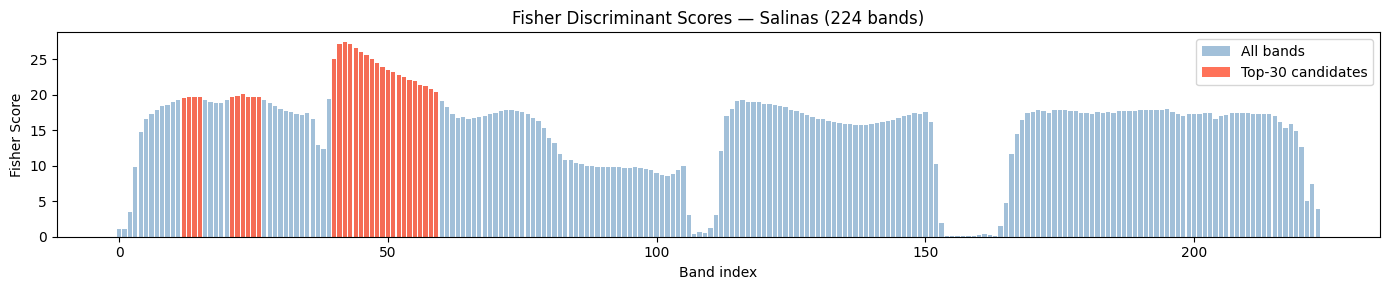


QUBO matrix : 30x30
Ising h     : [-2.697, -1.710]
Non-zero J  : 217 terms
QUBO formulation complete ✓


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Fisher Scores & QUBO Formulation
# ═══════════════════════════════════════════════════════════════════════════

# ── Subsample for Fisher (speed) ──────────────────────────────────────────
n_fisher = min(FISHER_SAMPLES, len(y_labeled))
X_fisher, _, y_fisher, _ = train_test_split(
    X_labeled, y_labeled,
    train_size=n_fisher, stratify=y_labeled, random_state=42
)
print(f'Fisher subsample: {n_fisher} pixels from {len(y_labeled):,} total')

# ── Compute Fisher scores (vectorized — fast) ─────────────────────────────
def compute_fisher_scores(X, y):
    classes = np.unique(y)
    mu      = X.mean(axis=0)
    between = np.zeros(X.shape[1])
    within  = np.zeros(X.shape[1])
    for c in classes:
        Xc = X[y == c]
        nc = len(Xc)
        mc = Xc.mean(axis=0)
        between += nc * (mc - mu) ** 2
        within  += nc * Xc.var(axis=0)
    return between / (within + 1e-12)

print(f'Computing Fisher scores for all {N_ALL_BANDS} bands...')
scaler_fisher   = StandardScaler()
X_fisher_scaled = scaler_fisher.fit_transform(X_fisher)
fisher_scores   = compute_fisher_scores(X_fisher_scaled, y_fisher)

candidate_idx        = np.argsort(fisher_scores)[::-1][:N_CANDIDATE_BANDS]
candidate_idx_sorted = np.sort(candidate_idx)

print(f'\nTop {N_CANDIDATE_BANDS} candidate bands (1-indexed):')
print('  ' + '  '.join([f'B{b+1}' for b in candidate_idx_sorted]))

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(N_ALL_BANDS), fisher_scores, color='steelblue', alpha=0.5, label='All bands')
ax.bar(candidate_idx, fisher_scores[candidate_idx], color='tomato', alpha=0.9,
       label=f'Top-{N_CANDIDATE_BANDS} candidates')
ax.set_xlabel('Band index'); ax.set_ylabel('Fisher Score')
ax.set_title(f'Fisher Discriminant Scores — Salinas ({N_ALL_BANDS} bands)')
ax.legend(); plt.tight_layout(); plt.show()

# ── Build QUBO matrix ─────────────────────────────────────────────────────
cand_data   = X_fisher_scaled[:, candidate_idx]
corr_matrix = np.corrcoef(cand_data.T)
cand_scores = fisher_scores[candidate_idx]

def build_qubo(scores, corr, k, A=QUBO_PENALTY, B=CORR_PENALTY):
    n = len(scores)
    s = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -s[i] + A * (1 - 2 * k)
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] = B * abs(corr[i, j]) + 2 * A
    return Q

def qubo_to_ising(Q):
    n = Q.shape[0]
    h = np.zeros(n); J = np.zeros((n, n)); offset = 0.0
    for i in range(n):
        h[i]   += -Q[i, i] / 2
        offset +=  Q[i, i] / 2
    for i in range(n):
        for j in range(i + 1, n):
            J[i, j] +=  Q[i, j] / 4
            h[i]    += -Q[i, j] / 4
            h[j]    += -Q[i, j] / 4
            offset  +=  Q[i, j] / 4
    return h, J, offset

Q_matrix = build_qubo(cand_scores, corr_matrix, N_BANDS_SELECT)
h_ising, J_ising, ising_offset = qubo_to_ising(Q_matrix)
n_qaoa_qubits = Q_matrix.shape[0]

print(f'\nQUBO matrix : {n_qaoa_qubits}x{n_qaoa_qubits}')
print(f'Ising h     : [{h_ising.min():.3f}, {h_ising.max():.3f}]')
print(f'Non-zero J  : {int((np.abs(J_ising)>0.01).sum()//2)} terms')
print('QUBO formulation complete ✓')

qiskit_runtime_service._discover_account:WARNING:2026-03-21 11:12:13,444: Loading account with the given token. A saved account will not be used.


QAOA circuit: 30 qubits, depth=175, 1425 gates

Connecting to IBM Quantum...
  Connected to  : ibm_fez
  Qubits        : 156
  Queue         : 0 jobs waiting
  Operational   : True

Transpiling circuit for hardware...
  Transpiled depth : 1713
  Transpiled gates : 8980

Total circuits to run: 16 (4γ × 4β)
Estimated QPU time   : ~16.4k shots
NOTE: You will wait in queue. This could take 30 min to a few hours.

Submitting 16 circuits as one job...
  Job ID  : d6v7q7itnsts73estvu0
  Backend : ibm_fez  ← REAL IBM QUANTUM HARDWARE

Waiting for results (check queue at quantum.ibm.com)...
You can close Colab and come back — job runs on IBM servers.
  [QUEUED]   [DONE] 
  Done in 0.3 minutes
Results received from ibm_fez

QUANTUM QUBO BAND SELECTION RESULT
  Backend    : ibm_fez  (REAL IBM QUANTUM HARDWARE)
  Job ID     : d6v7q7itnsts73estvu0
  Best γ     : 2.111 rad
  Best β     : 0.557 rad
  QUBO cost  : -1098.6806
  Selected 15 bands (1-indexed): [np.int64(13), np.int64(14), np.int64(15), n

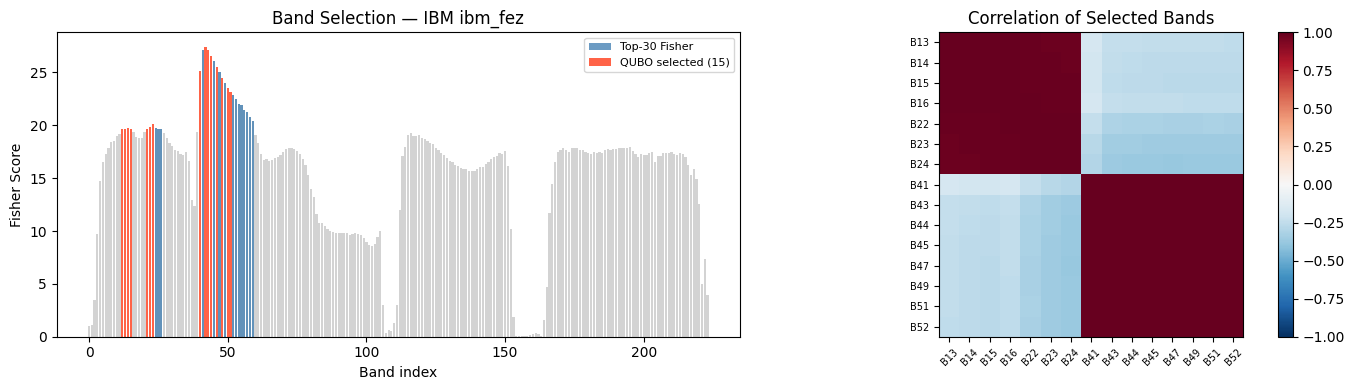

In [6]:
import os
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — QUBO Band Selection via IBM Quantum Real Hardware
# ═══════════════════════════════════════════════════════════════════════════
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'qiskit>=2.0.0',
                       'qiskit-ibm-runtime>=0.30.0'])

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ═══════════════════════════════════════════════════════════════════════════
# ▼▼▼ PASTE YOUR DETAILS HERE ▼▼▼
IBM_API_TOKEN = os.environ.get('IBM_QUANTUM_TOKEN', '')  # set via environment variable, do NOT hardcode
IBM_INSTANCE  = os.environ.get('IBM_QUANTUM_INSTANCE', '')  # set via environment variable, do NOT hardcode
# ▲▲▲ PASTE YOUR DETAILS HERE ▲▲▲
# ═══════════════════════════════════════════════════════════════════════════

# ── QAOA config for real hardware ─────────────────────────────────────────
QAOA_SHOTS  = 1024    # keep low to save QPU time
N_GAMMA     = 4       # smaller grid — saves QPU minutes
N_BETA      = 4       # 4x4 = 16 circuits total instead of 64

# ── Build QAOA circuit ────────────────────────────────────────────────────
def build_qaoa_circuit(h, J, p=1, j_threshold=0.01):
    n     = len(h)
    gamma = ParameterVector('g', p)
    beta  = ParameterVector('b', p)
    qc    = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(p):
        for i in range(n):
            for j in range(i + 1, n):
                if abs(J[i, j]) > j_threshold:
                    qc.cx(i, j)
                    qc.rz(2 * gamma[layer] * J[i, j], j)
                    qc.cx(i, j)
        for i in range(n):
            if abs(h[i]) > j_threshold:
                qc.rz(2 * gamma[layer] * h[i], i)
        for i in range(n):
            qc.rx(2 * beta[layer], i)
    qc.measure_all()
    return qc, gamma, beta

qaoa_qc, gamma_pv, beta_pv = build_qaoa_circuit(h_ising, J_ising, p=QAOA_DEPTH)
print(f'QAOA circuit: {qaoa_qc.num_qubits} qubits, '
      f'depth={qaoa_qc.depth()}, {qaoa_qc.size()} gates')

# ── Connect to IBM Quantum ─────────────────────────────────────────────────
print('\nConnecting to IBM Quantum...')
try:
    service = QiskitRuntimeService(
        channel  = 'ibm_quantum_platform',
        token    = IBM_API_TOKEN,
        instance = IBM_INSTANCE,
    )
    # Pick least busy backend with enough qubits
    backend = service.least_busy(
        operational    = True,
        simulator      = False,
        min_num_qubits = n_qaoa_qubits
    )
    print(f'  Connected to  : {backend.name}')
    print(f'  Qubits        : {backend.num_qubits}')
    status = backend.status()
    print(f'  Queue         : {status.pending_jobs} jobs waiting')
    print(f'  Operational   : {status.operational}')
except Exception as e:
    print(f'  Connection failed: {e}')
    print('  Check your API token and instance name')
    raise

# ── Transpile circuit for real hardware ───────────────────────────────────
print('\nTranspiling circuit for hardware...')
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
transpiled_qc = pm.run(qaoa_qc)
print(f'  Transpiled depth : {transpiled_qc.depth()}')
print(f'  Transpiled gates : {transpiled_qc.size()}')

# ── Build parameter grid ───────────────────────────────────────────────────
gamma_grid  = np.linspace(0.05, np.pi,     N_GAMMA)
beta_grid   = np.linspace(0.05, np.pi / 2, N_BETA)
param_pairs = list(itertools.product(gamma_grid, beta_grid))
total       = len(param_pairs)
print(f'\nTotal circuits to run: {total} ({N_GAMMA}γ × {N_BETA}β)')
print(f'Estimated QPU time   : ~{total * QAOA_SHOTS / 1000:.1f}k shots')
print('NOTE: You will wait in queue. This could take 30 min to a few hours.')

# ── Submit all circuits in one job ─────────────────────────────────────────
sampler = Sampler(mode=backend)
sampler.options.default_shots = QAOA_SHOTS

bound_circuits = []
for g_val, b_val in param_pairs:
    pmap = {gamma_pv[0]: g_val, beta_pv[0]: b_val}
    bound_circuits.append(transpiled_qc.assign_parameters(pmap))

print(f'\nSubmitting {len(bound_circuits)} circuits as one job...')
job    = sampler.run(bound_circuits)
job_id = job.job_id()
print(f'  Job ID  : {job_id}')
print(f'  Backend : {backend.name}  ← REAL IBM QUANTUM HARDWARE')
print(f'\nWaiting for results (check queue at quantum.ibm.com)...')
print('You can close Colab and come back — job runs on IBM servers.')

# ── Poll for completion ────────────────────────────────────────────────────
t0 = time.time()
while True:
    try:
        status_str = str(job.status()).upper()
        print(f'  [{status_str}]', end=' ', flush=True)
        if any(s in status_str for s in ['DONE', 'COMPLETED']):
            break
        if any(s in status_str for s in ['ERROR', 'CANCELLED', 'FAILED']):
            raise RuntimeError(f'Job failed: {status_str}')
    except RuntimeError:
        raise
    except Exception:
        pass
    time.sleep(15)

print(f'\n  Done in {(time.time()-t0)/60:.1f} minutes')

# ── Extract results ────────────────────────────────────────────────────────
result     = job.result()
all_counts = []
for k in range(len(bound_circuits)):
    counts = result[k].data.meas.get_counts()
    all_counts.append(counts)

print(f'Results received from {backend.name}')

# ── Find best solution ─────────────────────────────────────────────────────
def qubo_cost(bits, Q):
    x = np.array(bits, dtype=float)
    return float(x @ Q @ x)

best_cost      = float('inf')
best_gamma_val = None
best_beta_val  = None
best_local_idx = None

for cnt_dict, (g_val, b_val) in zip(all_counts, param_pairs):
    for bs in cnt_dict:
        bits = [int(c) for c in reversed(bs)]
        if sum(bits) == N_BANDS_SELECT:
            cost = qubo_cost(bits, Q_matrix)
            if cost < best_cost:
                best_cost      = cost
                best_gamma_val = g_val
                best_beta_val  = b_val
                best_local_idx = [i for i, b in enumerate(bits) if b == 1]

# Fallback if no exact solution
if best_local_idx is None:
    print('No exact-k solution — using best approximate')
    best_approx = None
    for cnt_dict in all_counts:
        for bs in cnt_dict:
            bits = [int(c) for c in reversed(bs)]
            if best_approx is None or \
               abs(sum(bits)-N_BANDS_SELECT) < abs(sum(best_approx)-N_BANDS_SELECT):
                best_approx = bits
    best_local_idx = [i for i, b in enumerate(best_approx) if b == 1][:N_BANDS_SELECT]

selected_band_idx = np.sort(candidate_idx[best_local_idx])

# ── Report ─────────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('QUANTUM QUBO BAND SELECTION RESULT')
print('=' * 65)
print(f'  Backend    : {backend.name}  (REAL IBM QUANTUM HARDWARE)')
print(f'  Job ID     : {job_id}')
print(f'  Best γ     : {best_gamma_val:.3f} rad')
print(f'  Best β     : {best_beta_val:.3f} rad')
print(f'  QUBO cost  : {best_cost:.4f}')
print(f'  Selected {N_BANDS_SELECT} bands (1-indexed): {list(selected_band_idx + 1)}')
for b in selected_band_idx:
    print(f'    Band {b+1:3d}  Fisher = {fisher_scores[b]:.4f}')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.bar(range(N_ALL_BANDS), fisher_scores, color='lightgray')
ax.bar(candidate_idx, fisher_scores[candidate_idx], color='steelblue',
       alpha=0.8, label=f'Top-{N_CANDIDATE_BANDS} Fisher')
ax.bar(selected_band_idx, fisher_scores[selected_band_idx], color='tomato',
       label=f'QUBO selected ({N_BANDS_SELECT})')
ax.set_xlabel('Band index'); ax.set_ylabel('Fisher Score')
ax.set_title(f'Band Selection — IBM {backend.name}')
ax.legend(fontsize=8)

ax2 = axes[1]
corr_sel = np.corrcoef(X_fisher_scaled[:, selected_band_idx].T)
im = ax2.imshow(corr_sel, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title('Correlation of Selected Bands')
ax2.set_xticks(range(N_BANDS_SELECT))
ax2.set_yticks(range(N_BANDS_SELECT))
ax2.set_xticklabels([f'B{b+1}' for b in selected_band_idx], rotation=45, fontsize=7)
ax2.set_yticklabels([f'B{b+1}' for b in selected_band_idx], fontsize=7)
plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Prepare Full Dataset with QUBO-Selected Bands
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print('=' * 65)
print('PREPARING FULL DATASET')
print('=' * 65)

# Keep only the QUBO-selected bands — ALL labeled pixels
X_selected = X_labeled[:, selected_band_idx].astype(np.float64)

print(f'  Total labeled pixels : {len(y_labeled):,}')
print(f'  Bands before QUBO    : {N_ALL_BANDS}')
print(f'  Bands after  QUBO    : {X_selected.shape[1]}  ← quantum selected')
print(f'  Reduction            : {(1 - X_selected.shape[1]/N_ALL_BANDS)*100:.0f}% fewer bands')

# Standardise
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_selected)

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_labeled,
    test_size=TEST_SPLIT, stratify=y_labeled, random_state=42
)

n_features = X_train.shape[1]

print(f'\n  Train set : {X_train.shape[0]:,} pixels  x  {n_features} bands')
print(f'  Test  set : {X_test.shape[0]:,} pixels  x  {n_features} bands')
print('\n  Class distribution in test set:')
for c in unique_cls:
    cnt  = (y_test == c).sum()
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    print(f'    {int(c):2d}  {name:35s}: {cnt:5,}')
print('=' * 65)

PREPARING FULL DATASET
  Total labeled pixels : 54,129
  Bands before QUBO    : 224
  Bands after  QUBO    : 15  ← quantum selected
  Reduction            : 93% fewer bands

  Train set : 43,303 pixels  x  15 bands
  Test  set : 10,826 pixels  x  15 bands

  Class distribution in test set:
     1  Broccoli_green_weeds_1             :   402
     2  Broccoli_green_weeds_2             :   745
     3  Fallow                             :   395
     4  Fallow_rough_plow                  :   279
     5  Fallow_smooth                      :   536
     6  Stubble                            :   792
     7  Celery                             :   716
     8  Grapes_untrained                   : 2,254
     9  Soil_vinyard_develop               : 1,241
    10  Corn_senesced_green_weeds          :   656
    11  Lettuce_romaine_4wk                :   213
    12  Lettuce_romaine_5wk                :   385
    13  Lettuce_romaine_6wk                :   183
    14  Lettuce_romaine_7wk                :  

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — Classical ML Classifiers on Full Dataset
# All classifiers use 5-fold stratified CV with RandomizedSearchCV.
# ═══════════════════════════════════════════════════════════════════════════

CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

clf_configs = {
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
         'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
        20
    ),
    'Extra Trees': (
        ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
         'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
        20
    ),
    'HistGradientBoosting': (
        HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
        {'max_iter': randint(150, 400), 'max_depth': randint(4, 10),
         'learning_rate': loguniform(0.02, 0.3), 'l2_regularization': loguniform(1e-4, 1.0),
         'min_samples_leaf': randint(5, 30)},
        20
    ),
    'KNN': (
        KNeighborsClassifier(n_jobs=-1),
        {'n_neighbors': randint(3, 20), 'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan']},
        15
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        {'C': loguniform(0.1, 100), 'solver': ['lbfgs', 'saga']},
        15
    ),
    'MLP Neural Net': (
        MLPClassifier(max_iter=500, early_stopping=True,
                      validation_fraction=0.1, n_iter_no_change=15, random_state=42),
        {'hidden_layer_sizes': [(256, 128), (512, 256, 128), (128, 64)],
         'alpha': loguniform(1e-5, 1e-2),
         'learning_rate_init': loguniform(1e-4, 1e-2)},
        15
    ),
}

results = {}

print('\n' + '=' * 80)
print(f'CLASSIFIERS — {n_features} QUBO-SELECTED BANDS — FULL DATASET')
print(f'Train: {X_train.shape[0]:,} pixels  |  Test: {X_test.shape[0]:,} pixels  |  {CV_FOLDS}-fold CV')
print('=' * 80)
print(f'{"Classifier":<22}  {"CV":>8}  {"Train":>8}  {"Test":>8}  {"Gap":>7}  {"Time":>8}')
print('-' * 80)

for name, (base_clf, param_dist, n_iter) in clf_configs.items():
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator=base_clf, param_distributions=param_dist,
        n_iter=n_iter, cv=CV, scoring='accuracy',
        refit=True, n_jobs=-1, random_state=42, verbose=0,
    )
    search.fit(X_train, y_train)
    clf       = search.best_estimator_
    cv_score  = search.best_score_ * 100
    train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
    gap       = train_acc - test_acc
    elapsed   = time.time() - t0
    results[name] = {
        'clf': clf, 'cv_score': cv_score,
        'train_acc': train_acc, 'test_acc': test_acc,
        'train_time': elapsed, 'best_params': search.best_params_,
    }
    print(f'{name:<22}  {cv_score:>7.2f}%  {train_acc:>7.2f}%  '
          f'{test_acc:>7.2f}%  {gap:>6.1f}pp  {elapsed:>6.1f}s')

print('=' * 80)
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f'\n✅  Best: {best_name}  →  Test accuracy: {results[best_name]["test_acc"]:.2f}%')


CLASSIFIERS — 15 QUBO-SELECTED BANDS — FULL DATASET
Train: 43,303 pixels  |  Test: 10,826 pixels  |  5-fold CV
Classifier                    CV     Train      Test      Gap      Time
--------------------------------------------------------------------------------
Random Forest             90.31%    99.70%    91.46%     8.2pp  3100.3s
Extra Trees               90.26%   100.00%    91.34%     8.7pp   848.4s
HistGradientBoosting      88.26%    92.77%    89.04%     3.7pp  1262.8s
KNN                       89.42%   100.00%    90.35%     9.7pp    39.9s
Logistic Regression       84.93%    85.09%    85.01%     0.1pp  1517.8s
MLP Neural Net            88.55%    88.81%    88.68%     0.1pp  6416.2s

✅  Best: Random Forest  →  Test accuracy: 91.46%


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Per-Class Report + Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════

best_clf = results[best_name]['clf']
y_pred   = best_clf.predict(X_test)

# ── Per-class accuracy ────────────────────────────────────────────────────
print(f'Per-Class Accuracy — {best_name}')
print('=' * 70)
per_class_acc = []
for c in unique_cls:
    mask = y_test == c
    if mask.sum() == 0:
        continue
    acc  = accuracy_score(y_test[mask], y_pred[mask]) * 100
    per_class_acc.append(acc)
    bar  = '█' * int(acc / 5)
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    print(f'  {int(c):2d}  {name:35s}: {acc:6.2f}%  {bar}')

print(f'\n  Mean per-class accuracy : {np.mean(per_class_acc):.2f}%')
print(f'  Overall test accuracy   : {results[best_name]["test_acc"]:.2f}%')
print('=' * 70)

# ── Full classification report ────────────────────────────────────────────
print()
print(classification_report(
    y_test, y_pred,
    target_names=[CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls],
    zero_division=0
))

Per-Class Accuracy — Random Forest
   1  Broccoli_green_weeds_1             :  98.76%  ███████████████████
   2  Broccoli_green_weeds_2             :  99.73%  ███████████████████
   3  Fallow                             :  97.47%  ███████████████████
   4  Fallow_rough_plow                  :  99.28%  ███████████████████
   5  Fallow_smooth                      :  95.34%  ███████████████████
   6  Stubble                            :  99.37%  ███████████████████
   7  Celery                             :  99.58%  ███████████████████
   8  Grapes_untrained                   :  83.85%  ████████████████
   9  Soil_vinyard_develop               :  97.99%  ███████████████████
  10  Corn_senesced_green_weeds          :  94.51%  ██████████████████
  11  Lettuce_romaine_4wk                :  95.77%  ███████████████████
  12  Lettuce_romaine_5wk                :  99.74%  ███████████████████
  13  Lettuce_romaine_6wk                :  98.91%  ███████████████████
  14  Lettuce_romaine_7wk        

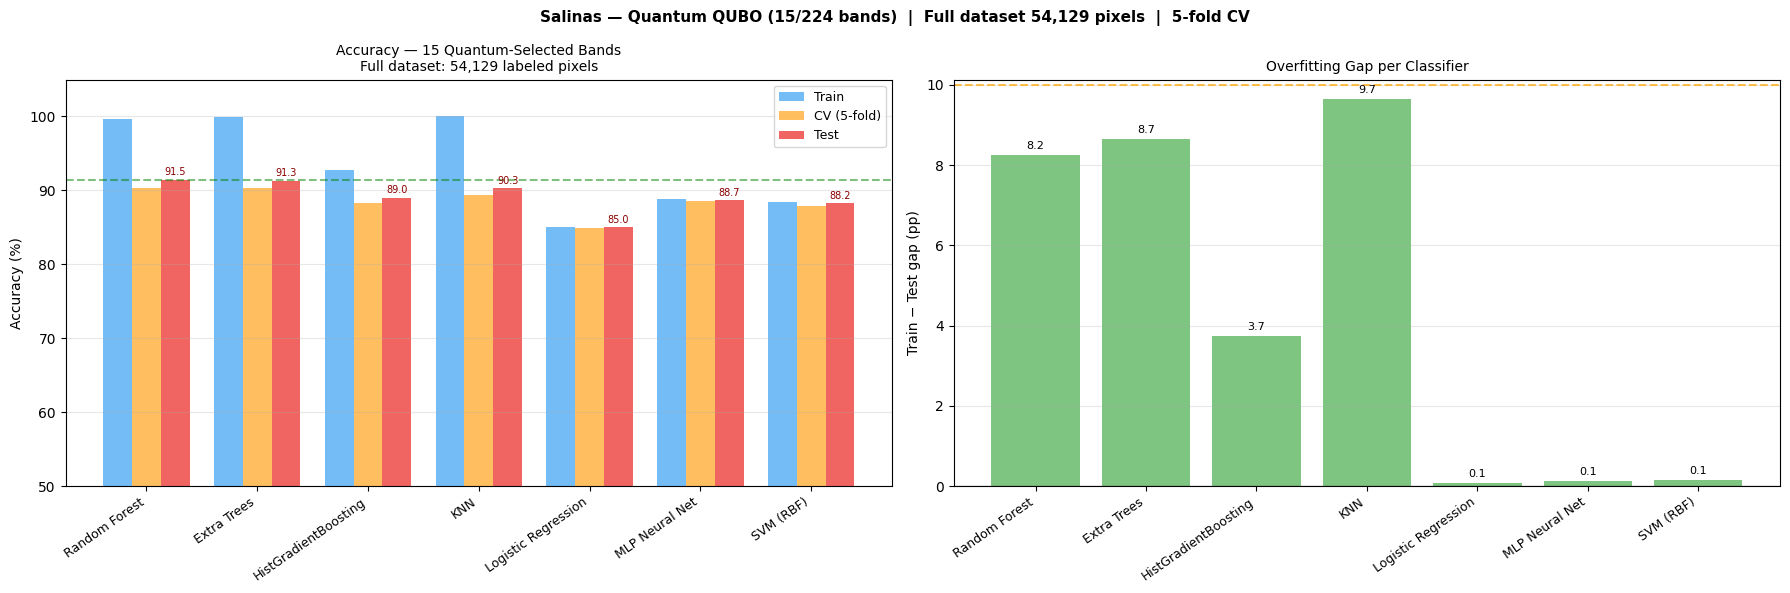


FINAL RESULTS — RANKED BY TEST ACCURACY
Rank  Classifier                    CV     Train      Test      Gap      Time
--------------------------------------------------------------------------------
 1.  Random Forest               90.31%    99.70%    91.46%     8.2pp  3100.3s  ◀ BEST
 2.  Extra Trees                 90.26%   100.00%    91.34%     8.7pp   848.4s
 3.  KNN                         89.42%   100.00%    90.35%     9.7pp    39.9s
 4.  HistGradientBoosting        88.26%    92.77%    89.04%     3.7pp  1262.8s
 5.  MLP Neural Net              88.55%    88.81%    88.68%     0.1pp  6416.2s
 6.  SVM (RBF)                   87.93%    88.38%    88.23%     0.1pp  1318.9s
 7.  Logistic Regression         84.93%    85.09%    85.01%     0.1pp  1517.8s

Quantum QUBO selected bands (1-indexed) : [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(22), np.int64(23), np.int64(24), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(47), np.int64(49), np.int64(51),

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — Results Summary Chart + Ranked Table
# ═══════════════════════════════════════════════════════════════════════════

names      = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs  = [results[n]['test_acc']  for n in names]
cv_scores  = [results[n]['cv_score']  for n in names]
gaps       = [t - v for t, v in zip(train_accs, test_accs)]

x = np.arange(len(names))
w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.bar(x - w, train_accs, w, label='Train',       color='#64B5F6', alpha=0.9)
ax.bar(x,     cv_scores,  w, label='CV (5-fold)', color='#FFB74D', alpha=0.9)
ax.bar(x + w, test_accs,  w, label='Test',        color='#EF5350', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(50, 105)
ax.set_title(
    f'Accuracy — {N_BANDS_SELECT} Quantum-Selected Bands\n'
    f'Full dataset: {len(y_labeled):,} labeled pixels', fontsize=10
)
ax.legend(fontsize=9)
ax.axhline(y=max(test_accs), color='green', linestyle='--', alpha=0.5)
for i, v in enumerate(test_accs):
    ax.text(x[i] + w, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7, color='darkred')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bar_cols = ['#FF7043' if g > 10 else '#66BB6A' for g in gaps]
ax2.bar(x, gaps, color=bar_cols, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Train − Test gap (pp)')
ax2.set_title('Overfitting Gap per Classifier', fontsize=10)
ax2.axhline(y=0,  color='black', linewidth=0.8)
ax2.axhline(y=10, color='orange', linestyle='--', alpha=0.7)
ax2.grid(axis='y', alpha=0.3)
for bar, g in zip(ax2.patches, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.1,
             f'{g:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Salinas — Quantum QUBO ({N_BANDS_SELECT}/{N_ALL_BANDS} bands)  |  '
    f'Full dataset {len(y_labeled):,} pixels  |  {CV_FOLDS}-fold CV',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Ranked summary table ──────────────────────────────────────────────────
print('\n' + '=' * 80)
print('FINAL RESULTS — RANKED BY TEST ACCURACY')
print('=' * 80)
print(f'{"Rank  Classifier":<28}  {"CV":>8}  {"Train":>8}  {"Test":>8}  {"Gap":>7}  {"Time":>8}')
print('-' * 80)
for rank, n in enumerate(
    sorted(names, key=lambda n: results[n]['test_acc'], reverse=True), 1
):
    r   = results[n]
    gap = r['train_acc'] - r['test_acc']
    mrk = '  ◀ BEST' if n == best_name else ''
    print(f'{rank:>2}.  {n:<24}  {r["cv_score"]:>7.2f}%  '
          f'{r["train_acc"]:>7.2f}%  {r["test_acc"]:>7.2f}%  '
          f'{gap:>6.1f}pp  {r["train_time"]:>6.1f}s{mrk}')
print('=' * 80)
print(f'\nQuantum QUBO selected bands (1-indexed) : {list(selected_band_idx + 1)}')
print(f'Bands used   : {N_BANDS_SELECT} of {N_ALL_BANDS} ({N_BANDS_SELECT/N_ALL_BANDS*100:.0f}% of original)')
print(f'Best accuracy: {results[best_name]["test_acc"]:.2f}%  ({best_name})')

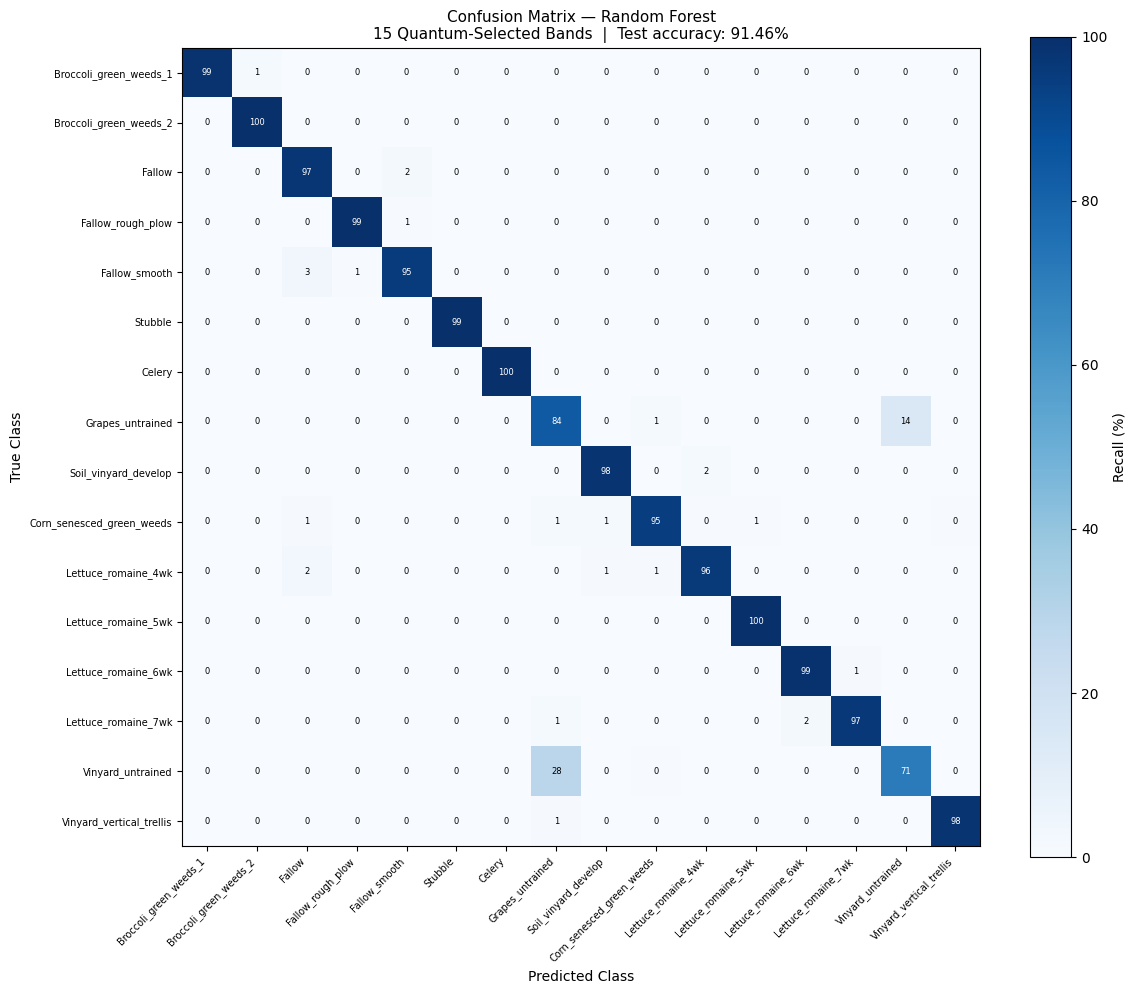

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — Confusion Matrix (Best Classifier)
# ═══════════════════════════════════════════════════════════════════════════

cm      = confusion_matrix(y_test, y_pred, labels=unique_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Recall (%)')

tick_labels = [CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls]
ax.set_xticks(range(len(unique_cls)))
ax.set_yticks(range(len(unique_cls)))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(tick_labels, fontsize=7)

for i in range(len(unique_cls)):
    for j in range(len(unique_cls)):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=6, color='white' if v > 60 else 'black')

ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(
    f'Confusion Matrix — {best_name}\n'
    f'{N_BANDS_SELECT} Quantum-Selected Bands  |  '
    f'Test accuracy: {results[best_name]["test_acc"]:.2f}%',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — SVM Only (run separately after all other cells are done)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import loguniform
import time

print('=' * 65)
print('SVM (RBF) — Running separately')
print(f'Train: {X_train.shape[0]:,} pixels  |  Test: {X_test.shape[0]:,} pixels')
print('Expected time: 1–3 hours')
print('=' * 65)

t0 = time.time()

svm_clf = SVC(
    class_weight='balanced',
    random_state=42,
    cache_size=4000,       # more cache = faster
    probability=False,     # faster without probability estimates
)

svm_search = RandomizedSearchCV(
    estimator=svm_clf,
    param_distributions={
        'C':     loguniform(10, 1000),
        'gamma': loguniform(1e-4, 1.0),
        'kernel': ['rbf'],
    },
    n_iter=10,             # only 10 combos to save time
    cv=5,
    scoring='accuracy',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,             # shows progress
)

svm_search.fit(X_train, y_train)

svm_best      = svm_search.best_estimator_
svm_cv        = svm_search.best_score_ * 100
svm_train_acc = accuracy_score(y_train, svm_best.predict(X_train)) * 100
svm_test_acc  = accuracy_score(y_test,  svm_best.predict(X_test))  * 100
svm_gap       = svm_train_acc - svm_test_acc
elapsed       = time.time() - t0

print(f'\nSVM Results:')
print(f'  Best params  : {svm_search.best_params_}')
print(f'  CV score     : {svm_cv:.2f}%')
print(f'  Train acc    : {svm_train_acc:.2f}%')
print(f'  Test acc     : {svm_test_acc:.2f}%')
print(f'  Gap          : {svm_gap:.1f}pp')
print(f'  Time         : {elapsed/60:.1f} minutes')

# Add to results dict so it appears in summary
results['SVM (RBF)'] = {
    'clf': svm_best, 'cv_score': svm_cv,
    'train_acc': svm_train_acc, 'test_acc': svm_test_acc,
    'train_time': elapsed, 'best_params': svm_search.best_params_,
}

print(f'\nUpdated best classifier:')
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f'  {best_name}  →  {results[best_name]["test_acc"]:.2f}%')

SVM (RBF) — Running separately
Train: 43,303 pixels  |  Test: 10,826 pixels
Expected time: 1–3 hours
Fitting 5 folds for each of 10 candidates, totalling 50 fits

SVM Results:
  Best params  : {'C': np.float64(56.11516415334507), 'gamma': np.float64(0.6351221010640696), 'kernel': 'rbf'}
  CV score     : 87.93%
  Train acc    : 88.38%
  Test acc     : 88.23%
  Gap          : 0.1pp
  Time         : 22.0 minutes

Updated best classifier:
  Random Forest  →  91.46%
